# **Churn Analysis**

**Tujuan Proyek**  

Membuat keseluruhan proses ETL dalam sebuah database serta dashboard Power BI untuk memanfaatkan data pelanggan dan mencapai tujuan berikut:

- Visualisasi & Analisis Data Pelanggan pada Level:

    - Demografis
    - Geografis
    - Informasi Pembayaran & Akun
    - Layanan

- Analisis Churn:

    - Mempelajari profil pelanggan yang churn
    - Mengidentifikasi area untuk implementasi kampanye marketing
    - Menentukan metode untuk memprediksi pelanggan yang berpotensi churn di masa depan

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

**Data Loading**

In [133]:
churn_df = pd.read_excel('Data/Prediction_Data.xlsx', sheet_name = "churn_data")
churn_df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,12210-AND,Male,66,No,Andhra Pradesh,9,31,NaN,No,No,...,Credit Card,34.299999,577.150024,0.0,0,0.0,577.150024,Stayed,Others,Others
1,12531-AND,Male,56,No,Andhra Pradesh,1,12,NaN,No,No,...,Bank Withdrawal,62.500000,4136.399902,0.0,0,0.0,4136.399902,Stayed,Others,Others
2,13500-BIH,Male,51,No,Bihar,9,18,NaN,No,No,...,Credit Card,56.400002,2928.500000,0.0,0,0.0,2928.500000,Stayed,Others,Others
3,14399-MAD,Female,56,Yes,Madhya Pradesh,8,9,NaN,No,No,...,Credit Card,35.450001,1958.949951,0.0,0,0.0,1958.949951,Stayed,Others,Others
4,14622-PUN,Female,49,Yes,Punjab,9,15,NaN,No,No,...,Bank Withdrawal,34.250000,163.550003,0.0,0,0.0,163.550003,Stayed,Others,Others


**Label Encoding**

In [134]:
def label_encoding(data, columns_to_encode, label_encoders = None) :
    if label_encoders == None :
        # Encode categorical variables except the target variable
        label_encoders = {}

        for column in columns_to_encode:
            label_encoders[column] = LabelEncoder()
            data[column] = label_encoders[column].fit_transform(data[column])
        
        return label_encoders, data
    else :
        for column in columns_to_encode:
            data[column] = label_encoders[column].transform(data[column])
        
        return data

In [135]:
# Drop columns that won't be used for prediction
churn_df = churn_df.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders, churn_df = label_encoding(churn_df, columns_to_encode)

# Manually encode the target variable 'Customer_Status'
churn_df['Customer_Status'] = churn_df['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

**Splitting Data**

In [136]:
# Split churn_df into features and target
X = churn_df.drop('Customer_Status', axis=1)
y = churn_df['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify = y, 
                                                    random_state=42)

**Modeling Data**

In [137]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[794  61]
 [125 222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       855
           1       0.78      0.64      0.70       347

    accuracy                           0.85      1202
   macro avg       0.82      0.78      0.80      1202
weighted avg       0.84      0.85      0.84      1202



**Feature Importance**

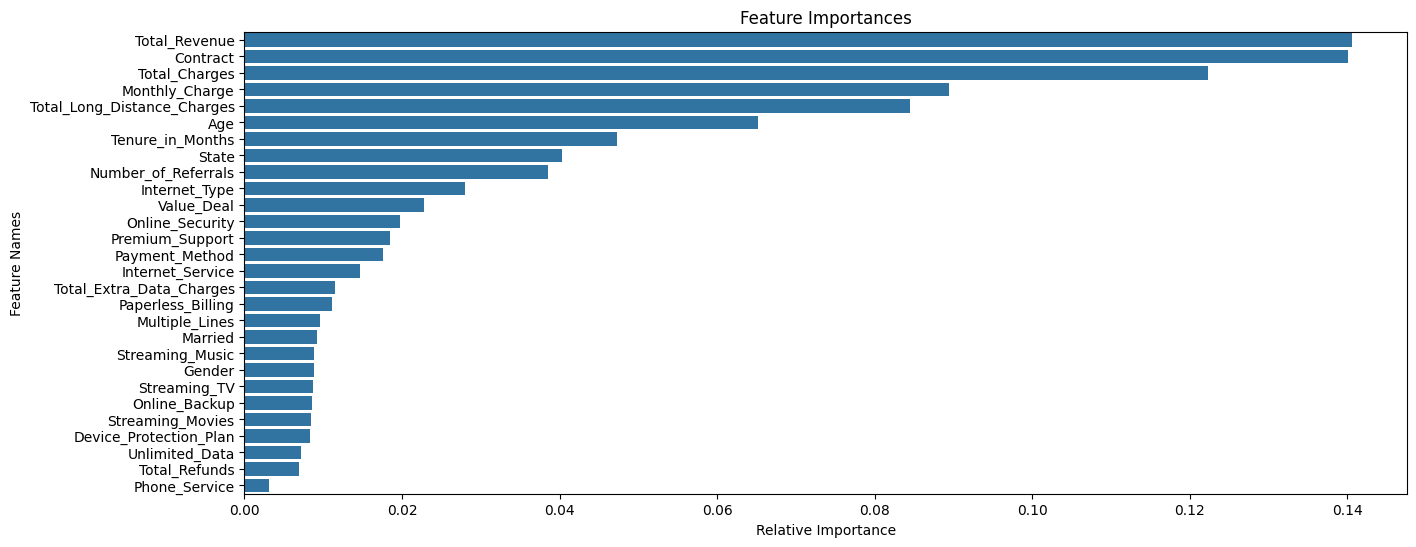

In [138]:
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

**Build Model Importance Features Only**

In [151]:
feature_001_up = [feature for i, feature in enumerate(X.columns) if importances[i] > 0.01]

X_fi = X[feature_001_up].copy()
y_fi = y.copy()

# Split data into training and testing sets
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(X_fi, 
                                                                y_fi, 
                                                                test_size=0.2, 
                                                                stratify = y_fi, 
                                                                random_state=42
)

# Initialize the Random Forest Classifier
rf_model_fi = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model_fi.fit(X_train_fi, y_train_fi)

# Make predictions
y_pred_fi = rf_model_fi.predict(X_test_fi)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_fi, y_pred_fi))

print("\nClassification Report:")
print(classification_report(y_test_fi, y_pred_fi))

Confusion Matrix:
[[788  67]
 [116 231]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       855
           1       0.78      0.67      0.72       347

    accuracy                           0.85      1202
   macro avg       0.82      0.79      0.81      1202
weighted avg       0.84      0.85      0.84      1202



**Churn Analysis for a New Customers**

In [ ]:
# Read a New Customers Data
join_df = pd.read_excel('Data/Prediction_Data.xlsx', sheet_name = "join_data")

# Retain Customer ID Column
join_df_cust_id = join_df['Customer_ID']

# Drop Columns
join_df.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], 
             axis = 1, 
             inplace = True)

# Label Encoding
join_df = label_encoding(join_df, 
                         columns_to_encode, 
                         label_encoders)

# Make predictions
new_predictions = rf_model.predict(join_df)

# Add predictions to the original DataFrame
join_df['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
churned_join_df = join_df[join_df['Customer_Status_Predicted'] == 1].copy()

# Save the results
churned_join_df.to_csv(r"Predictions.csv", index=False)